# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
# Taken from hardened import list from https://www.youtube.com/watch?v=VER-F4wdA9Q

from importlib import metadata
from importlib import import_module
import subprocess
import sys


def parse_major_minor(version: str) -> tuple[int, int]:
    parts = []
    for token in version.split("."):
        digits = "".join(ch for ch in token if ch.isdigit())
        if not digits:
            break
        parts.append(int(digits))
        if len(parts) == 2:
            break
    while len(parts) < 2:
        parts.append(0)
    return tuple(parts)


required_dists = [
    "tribev2",
    "yt-dlp",
    "Pillow",
    "exca",
    "nibabel",
    "nilearn",
    "neuralset",
    "neuraltrain",
]
missing = []
installed = {}
for dist_name in required_dists + ["numpy", "scipy"]:
    try:
        installed[dist_name] = metadata.version(dist_name)
    except metadata.PackageNotFoundError:
        missing.append(dist_name)

numpy_ok = False
scipy_ok = False
if "numpy" in installed:
    numpy_ok = parse_major_minor(installed["numpy"]) < (2, 1)
if "scipy" in installed:
    scipy_mm = parse_major_minor(installed["scipy"])
    scipy_ok = (1, 13) <= scipy_mm < (1, 16)

import_failures = []
for module_name in ["PIL", "moviepy", "exca", "nibabel", "nilearn", "neuralset", "neuraltrain"]:
    try:
        import_module(module_name)
    except Exception as exc:
        import_failures.append(f"{module_name}: {type(exc).__name__}: {exc}")

needs_install = bool(missing) or not numpy_ok or not scipy_ok or bool(import_failures)

if needs_install:
    print("Installing notebook dependencies...")
    if missing:
        print("Missing distributions:", ", ".join(missing))
    if import_failures:
        print("Broken imports detected:")
        for failure in import_failures:
            print(" -", failure)
    if "numpy" in installed:
        print("Detected NumPy:", installed["numpy"])
    if "scipy" in installed:
        print("Detected SciPy:", installed["scipy"])

    # Install the full notebook stack first, then force NumPy/SciPy back to a
    # known-good range for TRIBE's compiled dependencies.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git",
            "exca",
            "yt-dlp",
            "pillow",
            "pandas",
            "matplotlib",
            "moviepy",
        ],
        check=True,
    )

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--force-reinstall",
            "numpy>=1.26.4,<2.1",
            "scipy>=1.13,<1.16",
        ],
        check=True,
    )

    raise SystemExit(
        "Install complete. Restart the runtime now, then run the notebook again from the top."
    )

print("Setup already looks correct.")
print(f"NumPy version: {installed['numpy']}")
print(f"SciPy version: {installed['scipy']}")

Setup already looks correct.
NumPy version: 2.0.2
SciPy version: 1.15.3


## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [3]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
    config_update={
        "data": {
            "features_to_use": ["audio", "video"]
        }
    },
)
plotter = PlotBrain(mesh="fsaverage5")

2026-04-30 21:30:07 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt


## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
3. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

In [39]:
# USING SAMPLE VIDEO
# video_path = CACHE_FOLDER / "sample_video.mp4"
# url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
# download_file(url, video_path)


# UPLOAD YOUR OWN VIDEO
from google.colab import files
from pathlib import Path
import shutil

uploaded = files.upload()
filename = next(iter(uploaded))
video_path = CACHE_FOLDER / filename
shutil.move(filename, video_path)


# ---------------

# broken shorthand df get
# df = model.get_events_dataframe(video_path=video_path)
# display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])


# manual df get
import pandas as pd
from neuralset.events.utils import standardize_events
from neuralset.events.transforms import (
    ExtractAudioFromVideo,
    ChunkEvents,
)

# 1. Define the internal TRIBE transforms (excluding transcription)
# These match the logic in the Meta source code for get_audio_and_text_events
transforms = [
    ExtractAudioFromVideo(),
    ChunkEvents(event_type_to_chunk="Audio", max_duration=60, min_duration=30),
    ChunkEvents(event_type_to_chunk="Video", max_duration=60, min_duration=30),
]

# 2. Build the initial event row
initial_event = {
    "type": "Video",
    "filepath": str(video_path),
    "start": 0,
    "timeline": "default",
    "subject": "default",
}

# 3. Process the file through the neuralset pipeline
df = standardize_events(pd.DataFrame([initial_event]))
for transform in transforms:
    df = transform(df)

# 4. Standardize and display
df = standardize_events(df)
display(df.head(8)[["type", "start", "duration", "filepath"]])

Saving video7_low_juniors_list_up.mp4 to video7_low_juniors_list_up.mp4


Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/video7_low_juniors_list_up.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  3.25it/s]

MoviePy - Done.



/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


,type,start,duration,filepath
0,Audio,0.0,29.1,cache/video7_low_juniors_list_up.wav
1,Video,0.0,29.1,cache/video7_low_juniors_list_up.mp4


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [40]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[23:08:16 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[23:08:19 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-04-30 23:08:24 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 29.1s at 30.0fps, shape (576, 1024)):
cache/video7_low_juniors_list_up.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 29.1s at 30.0fps, shape (576, 1024)):
cache/video7_low_juniors_list_up.mp4
Encoding video:   0%|          | 0/58 [00:00<?, ?it/s]2026-04-30 23:08:26 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (58, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (58, 20, 1408)
Encoding video: 100%|██████████| 58/58 [02:45<00:00,  2.85s/it]
[23:11:09 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-30 23:11:09 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[23:11:10 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloade

Predictions shape: (30, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  7.37it/s]


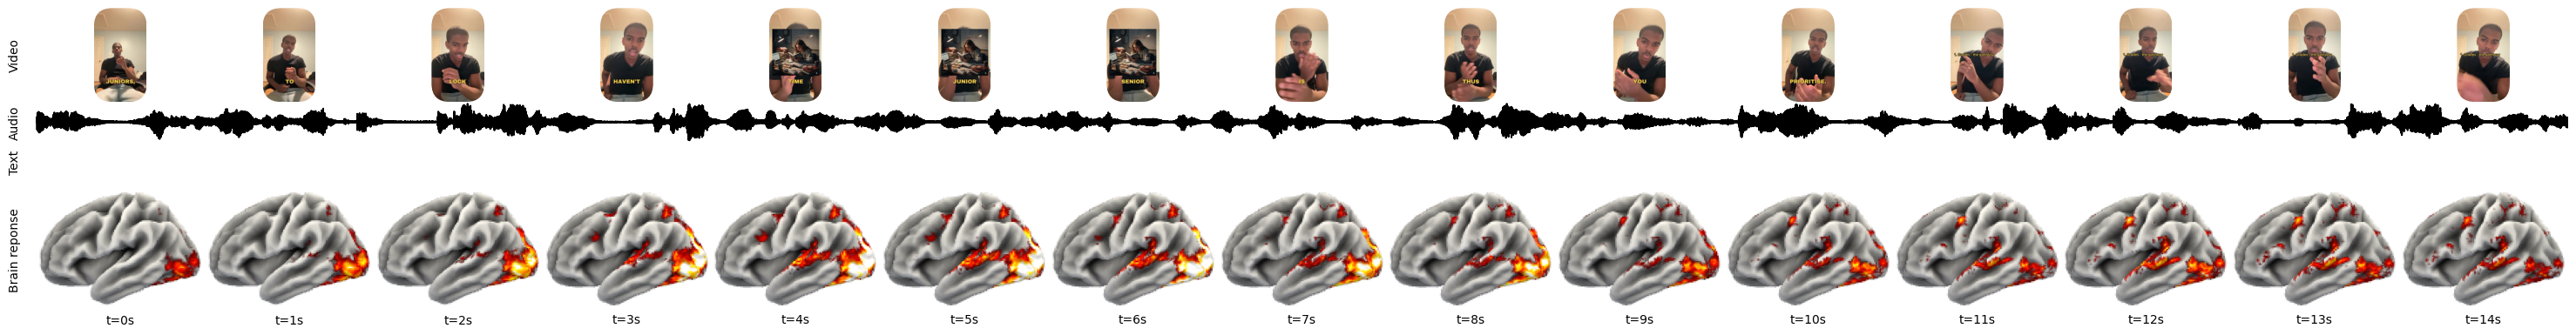

In [41]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

# Correlation Metrics - RUN FIRST PER TRIAL, 2/3 after all

In [ ]:
import numpy as np
import pandas as pd

# --- USER INPUT ---
# Neutral id only. NO "_low"/"_high"/"PSEUDO" in the name (that leaks a label into
# the analysis and invites best-of-N story-telling).
file_name = "stats_REPLACE_ME"
# ------------------

# SCALE CHECK FIRST. TRIBE predictions are z-scored, SIGNED BOLD values
# (~[-1, +1]; negatives are real deactivations), NOT 0..1 probabilities. Confirm
# before trusting any threshold-based metric.
print("preds:", preds.shape,
      "min=%.3f max=%.3f mean=%.3f std=%.3f" %
      (preds.min(), preds.max(), preds.mean(), preds.std()),
      "frac<0=%.2f%%" % (100*np.mean(preds < 0)))

# 6 scalars. active_area_ratio now uses a WITHIN-CLIP percentile of |activation|
# (scale-safe), NOT the old fixed `preds > 0.6` (which mis-read z-scores as
# probabilities and silently discarded every deactivation).
absp = np.abs(preds)
mean_activity          = float(np.mean(absp))
global_peak            = float(np.max(absp))
top_v_count            = max(1, int(preds.shape[1] * 0.01))     # top 1% of vertices
top_hotspot_intensity  = float(np.mean(np.sort(absp, axis=1)[:, -top_v_count:]))
hi_thr                 = np.percentile(absp, 90)               # within-clip, not 0.6
active_area_ratio      = float(np.mean(absp > hi_thr))
temporal_variance      = float(np.var(np.mean(absp, axis=1)))  # the pacing/arc signal
activity_contrast      = float(global_peak / (mean_activity + 1e-6))

# NOTE: 5 of these 6 are collinear (~r=1.0) - they are ~2 independent signals, not
# 6. temporal_variance is the defensible pacing signal. The PRIMARY test is the
# per-second ARC (see batch_extract.py + honest_corr_timeseries.py), not these
# single-number summaries.
metrics = {
    "filename_id": file_name,
    "mean_activity": mean_activity,
    "global_peak": global_peak,
    "top_hotspot_intensity": top_hotspot_intensity,
    "active_area_ratio": active_area_ratio,
    "temporal_variance": temporal_variance,
    "activity_contrast": activity_contrast,
}
pd.DataFrame([metrics]).to_csv(f"{file_name}.csv", index=False)
print(f"Saved {file_name}.csv")


In [ ]:
# QUARANTINED (was: hardcoded views/likes for 7 PSEUDO videos).
#
# Removed because it (a) used VIEWS/LIKES - driven by thumbnail/title/algorithm,
# not the content the model sees - and (b) fed a best-of-12 correlation grid that
# was reported as a finding on fabricated data. Both violate the project honesty
# rules (see CLAUDE.md).
#
# The real between-video test now lives in honest_corr.py (outcome = retention_pct,
# with permutation + leave-one-out + a zero-match guard). The PRIMARY test is the
# within-video arc in honest_corr_timeseries.py against TVSum's human interest arc.
#
# Do not re-add hardcoded engagement numbers here.
raise RuntimeError("Quarantined cell - use honest_corr.py / honest_corr_timeseries.py.")


In [ ]:
# QUARANTINED (was: 6 metrics x 2 outcomes scatter/regression grid).
#
# This computed 12 correlations and the Conclusions cell then cherry-picked the two
# biggest (r=0.77 vs views, r=0.85 vs likes) as "findings" - on PSEUDO data. That is
# exactly the best-of-N reverse-inference trap the project forbids.
#
# For an HONEST figure, use honest_corr_timeseries.py, which reports EVERY video
# (forest plot) with a circular-shift permutation null - no best-of-N.
raise RuntimeError("Quarantined cell - use honest_corr_timeseries.py for figures.")


# Conclusions

**Status: pending a real validation run.**

The earlier "Hook / Pulse" write-up (activity_contrast vs views r=0.77;
temporal_variance vs likes r=0.85, with confident biological narratives) was
**removed**. It was computed on **fabricated PSEUDO data (n=7)**, used **views/likes**
instead of retention, and **cherry-picked the two largest of 12 correlations** as
findings. Presenting that as validated neuroscience violates the project's honesty
rules (`CLAUDE.md`) and is a credibility risk in diligence.

**The honest chain (only step 1 is validated):**
1. video -> brain activation - Meta TRIBE v2, benchmarked vs real fMRI. Validated.
2. activation -> per-second arc feature - descriptive.
3. arc -> "engagement" - a hypothesis, tested (not asserted) against a human
   attention curve.

**How it is actually tested now:**
- PRIMARY: within-video arc vs the **TVSum** 20-annotator human interest arc,
  first-differenced, with a **circular-shift permutation null** (n = time), reported
  for **every** video with a leave-one-annotator-out noise ceiling.
  See `honest_corr_timeseries.py` and `PREREGISTRATION.md`.
- Two pre-registered features: `global` (whole-cortex; the documented likely-null
  baseline) and `roi` (an a-priori region; the open test).
- SECONDARY: between-video `honest_corr.py` against **retention_pct** (expected to be
  underpowered at small n; reported transparently).

Whatever those runs return - including a null - is what gets reported. No best-of-N.
